<a href="https://colab.research.google.com/github/ljzier/ST-554-repo/blob/main/ST_554_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Linda Zier**

**ST 554**

**HW #5**

#Part I - Concepts
1. The “Five V’s of Big Data”:
One place I've encountered big data is in working with a client that is trying to link Social media with ticket sales.  Specifically, the 5 V's show up in the folowing ways:

*   **Volume:** There is a very large amount of ticket sales in one database and social media posts and responses in another. There is also event data in yet another.  All of these are very large databases.
*   **Variety**: The data sources vary with some being Zoompf data from a marketing company and some being regular .csv files.


*   **Veracity**: There are lots of inconsistencies, missing values in some fields and differences in date formats making joins difficult
*   **Velocity**:  The data is always changing with time: events and social media posts are ongoing


*   **Value**: This is what we are trying to determine.  Specifically, how does social media influence ticket sales.


2. The Lahman.db that is an sqlite database that has information on Major League Baseball.


*   **Create**: This file was created by Sean Lahman and contains baseball stats going back to 1871. The people at baseball-databank.org convert it from the MS Access to MySQL so we can use it with SQLite.
*   **Read**: We will of course need to read this information so wwe can acces the baseball stats.  This is the main purpose of this database.

*   **Update**: Baseball is ongoing so the database must continually be updated
*   **Delete**: This is a changing database. Deletions are  necessary for any number of reasons as this is contantly changing data.


3. The HAVING clause when writing SQL code is used with the SELECT and GROUP BY syntax. It allows you to specify a filter condition for a group.


















#Part II - Simulation of a Sampling Distribution

Below we look at the sampling distribution of the sample slope from an SLR model using simulation.

• We assume the following model for SLR:
$$ Y_i = β_0 + β_1x_i + E_i $$
where the $E_i$ are assumed to be indendent and identically distributed from a standard Normal distribution
with mean 0 and variance $σ_2$ = 1.

• We used the code below to generate data from this model by assuming values for β0, β1, and n, along with a sequence
of x values.


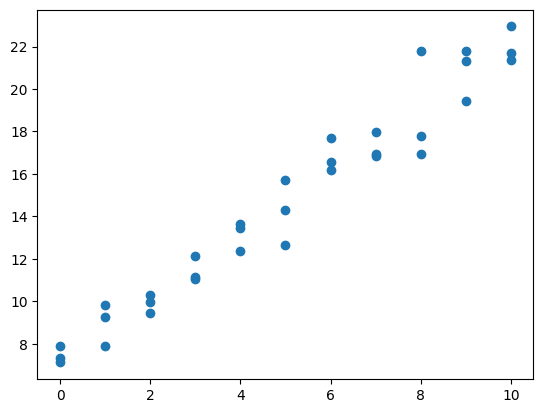

In [ ]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()


We created a regression line to estimate the slope. We then repeated the process 5000 times, saved the estimated slope values and plotted a histogram of the sample slope values.

7.359687529468447 [1.49946225]


<function matplotlib.pyplot.show(close=None, block=None)>

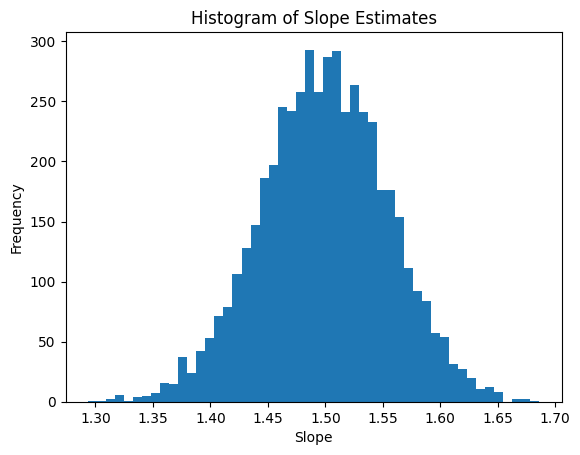

In [ ]:
from sklearn import linear_model

# create a regresion object
reg = linear_model.LinearRegression()

# fit an SLR line
reg.fit(x.reshape(-1, 1), y)
print(reg.intercept_, reg.coef_)

#initialize values
B=5000
slope_ests = np.zeros(B)  # B zeros in an array

#repeat B times
for i in range(B):
    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)

    # fit the line
    reg.fit(x.reshape(-1, 1), y)

    #save the slope
    slope_ests[i] = reg.coef_[0]

#visualize the data
plt.hist(slope_ests, bins = 50)
plt.title('Histogram of Slope Estimates')
plt.xlabel('Slope')
plt.ylabel('Frequency')
plt.show

To approximate the probability of observing a sample slope larger than 1.65, we can look at the proportion of values greater than 1.65.

In [ ]:
# Calculate the proportion above 1.65
p_hat = np.sum(slope_ests > 1.65) / B

print(f'The approximate probability of getting a sample slope > 1.65 is', p_hat)


The approximate probability of getting a sample slope > 1.65 is 0.0014


This represents the probability of getting a slope of 1.65 when the mean slope is 1.5.  This is the idea behind hypothesis tests.  In this case, because the probability is 0.0014, it is highly unlikely and $H_{0}$ would be rejected if that was the null hypothesis.

This value is also significant because it is the equivalent of getting a p-value of 0.05 for a standard normal.  This is the typical cut-off point for hypothesis testing; specifically for proving that $H_{0}$ is highly improbable and rejecting $H_{0}$. However, in our case, we don't have a standard normal because the mean is approximately 1.5 (by design, since we set $\beta_{1}$ = 1.5)


#Part III - Big Data Examples & Rare Events

Consider this article about bias in machine learning models
2
• Pick an example in the article and briefly outline the issue around the data used to fit the model.
(3 pts)
• Describe how we might augment the data or otherwise account for the bias in that situation. (3
pts)
6. Consider this article about big data usage in the Earth Sciences
• Choose one of the three major areas the paper discusses. Summarize the use of big data there.
Are there any biases or other missing data that might affect results? (I know this is likely difficult
as most of us aren’t experts in Earth science - just do your best - my goal is to try to get us to
always ask questions about the data collected and used for a study!) (5 pts)
7. Read through this short article: Article
• Mostly I just want you to read this article to understand some ways in which rare events, and
statisticians, play a role in different places. To have something to put here, can you think of
another variable or scenario where understanding rare events is important? (3 pts